In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
import scipy
from scipy.stats import pearsonr
from scipy import stats
from scipy.spatial.distance import cdist
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
import re
import matplotlib.colors as mcolors
import networkx as nx
from itertools import combinations
import json
import random
from adjustText import adjust_text

sc.settings.verbosity = 2

# Load in TF-associated networks

In [2]:
# MYOD1
path1 = "/scratch/indikar_root/indikar1/jrcwycy/HYB/HWG/MYOD_network_1storder_300.csv"
mdf = pd.read_csv(path1, index_col=0)
print(mdf.shape)
display(mdf.head())


# PRRX1
path2 = "/scratch/indikar_root/indikar1/jrcwycy/HYB/HWG/PRRX1_network_1storder_300.csv"
pdf = pd.read_csv(path2, index_col=0)
print(pdf.shape)
display(pdf.head())

(545, 545)


,MYOD1,CD99,KDM1A,PDK4,CALCR,HOXA11,MEOX1,CREBBP,SOX8,IFRD1,...,INS,ENSG00000255071,EID1,SCX,DUX4,PECAM1,MYMX,MYH4,H3-7,DACH1
MYOD1,0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
CD99,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0
KDM1A,1,0,1,1,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,1,0
PDK4,1,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
CALCR,1,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


(196, 196)


,PRRX1,COPZ2,TFAP2B,METTL13,DCN,SNAI2,VIM,CD44,CDH1,PHF23,...,COL5A2,POU5F1,VGLL3,EBF2,TWIST2,BGLAP,FOXD1,HOXB7,SCX,GTF2I
PRRX1,0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
COPZ2,1,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
TFAP2B,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
METTL13,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DCN,1,0,0,0,0,1,1,1,1,0,...,1,0,0,0,0,1,0,0,1,0


## Make graphs

In [3]:
# MYOD1
GM = nx.from_pandas_adjacency(mdf, create_using=nx.Graph) # keeps self-loops
GM.remove_edges_from(nx.selfloop_edges(GM)) # remove self-loops

print(f"MYOD1:\nN nodes: {GM.number_of_nodes()}\nN edges: {GM.number_of_edges()}")

n_edges = GM.number_of_edges()
n_nodes = GM.number_of_nodes()

density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"Graph density: {density:.4f}")

print(f'\nIs connected? {nx.is_connected(GM)}')
print(f'N connected components: {nx.number_connected_components(GM)}')
print(f'Largest connected components has {len(max(nx.connected_components(GM), key=len))} nodes\n')



# PRRX1
GP = nx.from_pandas_adjacency(pdf, create_using=nx.Graph) # keeps self-loops
GP.remove_edges_from(nx.selfloop_edges(GP)) # remove self-loops

print(f"\nPRRX1:\nN nodes: {GP.number_of_nodes()}\nN edges: {GP.number_of_edges()}")

n_edges = GP.number_of_edges()
n_nodes = GP.number_of_nodes()

density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"Graph density: {density:.4f}")

print(f'\nIs connected? {nx.is_connected(GP)}')
print(f'N connected components: {nx.number_connected_components(GP)}')
print(f'Largest connected components has {len(max(nx.connected_components(GP), key=len))} nodes')



## get gene lists for 1st order genes
myod_nodes = list(GM.nodes())
prrx_nodes = list(GP.nodes())

MYOD1:
N nodes: 545
N edges: 29898
Graph density: 0.2017

Is connected? True
N connected components: 1
Largest connected components has 545 nodes


PRRX1:
N nodes: 196
N edges: 4055
Graph density: 0.2122

Is connected? True
N connected components: 1
Largest connected components has 196 nodes


In [4]:
## get gene lists for 1st order genes
myod_nodes = list(GM.nodes())
print(len(myod_nodes))

prrx_nodes = list(GP.nodes())
print(len(prrx_nodes))

545
196


# Load in adata

In [5]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups_v2.h5ad"
adata = sc.read_h5ad(path)
sc.logging.print_memory_usage()
adata

Memory usage: current 2.43 GB, difference +2.43 GB
CPU times: user 581 ms, sys: 1.92 s, total: 2.5 s
Wall time: 5.46 s


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 16296 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

In [6]:
# Load TFs
fpath = "../../resources/HumanTF_v_1.01.csv"

tdf = pd.read_csv(fpath)

tdf = tdf[['HGNC symbol', 'Is TF?']]
tdf = tdf.rename(columns={'HGNC symbol': 'gene_name', 'Is TF?': 'is_tf'})
tdf = tdf[tdf['is_tf'] == 'Yes']
tdf = tdf.drop_duplicates(subset='gene_name')
display(tdf.head())

# extract unique TFs
tf_list = tdf['gene_name'].unique()
print(len(tf_list))

tf_list = [g for g in tf_list if g in adata.var_names]

print(len(tf_list))

,gene_name,is_tf
0,TFAP2A,Yes
1,TFAP2B,Yes
2,TFAP2C,Yes
3,TFAP2D,Yes
4,TFAP2E,Yes


1639
1358


In [7]:
conditions_to_keep = ['Control', 'siPRRX1/mmMYOD1']

fdata = adata[adata.obs['pooled_condition'].isin(conditions_to_keep), :].copy()
print(fdata.shape)

(10358, 25126)


In [8]:
# filter genes
fdata.X = fdata.layers['raw_counts'].copy()

sc.pp.filter_genes(fdata, min_counts=10) # param used for original processing

sc.pp.normalize_total(fdata, target_sum=1e4)
fdata.layers['CP10K'] = fdata.X.copy()

sc.pp.log1p(fdata)
fdata.layers['log_norm_new'] = fdata.X.copy()
fdata

filtered out 1509 genes that are detected in less than 10 counts
normalizing counts per cell
    finished (0:00:00)


AnnData object with n_obs × n_vars = 10358 × 23617
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

# Detected genes

In [9]:
### Which genes are present in adata?
# MYOD1
gene_names = set(fdata.var_names)
gene_ids = set(fdata.var['gene_id'])

myod_genes = [
    g for g in myod_nodes
    if (g.startswith('ENSG') and g in gene_ids) or
       (not g.startswith('ENSG') and g in gene_names)
]

missing_myod_genes = list(set(myod_nodes) - set(myod_genes))

print(f"N myod nodes in fdata: {len(myod_genes)}")
print(f"{len(missing_myod_genes)} genes not detected.\n")


# PRRX1
prrx_genes = [
    g for g in prrx_nodes
    if (g.startswith('ENSG') and g in gene_ids) or
       (not g.startswith('ENSG') and g in gene_names)
]

missing_prrx_genes = list(set(prrx_nodes) - set(prrx_genes))

print(f"N prrx1 nodes in fdata: {len(prrx_genes)}")
print(f"{len(missing_prrx_genes)} genes not detected.")

N myod nodes in fdata: 433
112 genes not detected.

N prrx1 nodes in fdata: 178
18 genes not detected.


In [10]:
### genes expressed in greater than 10% of cells in either condition
pct_exp_thresh = 0.10

print(f"Nodes (genes) expressed in ≥ {pct_exp_thresh*100:.0f}% of cells in either condition...")

## --------- MYOD1 genes ---------
# Boolean matrix: cells × genes
fdata.X = fdata.layers['raw_counts'].copy()

X = fdata[:, myod_genes].X > 0

# Convert to dense if needed
if not isinstance(X, np.ndarray):
    X = X.toarray()

df = pd.DataFrame(X, index=fdata.obs['pooled_condition'], columns=myod_genes)

# Compute fraction per condition
frac_by_condition = df.groupby(level=0, observed=True).mean()

# Keep genes passing threshold in ANY condition
myod_genes_robust = frac_by_condition.columns[(frac_by_condition >= pct_exp_thresh).any(axis=0)].tolist()
print(f"\nN MYOD1 genes: {len(myod_genes_robust)}")
print(f"% of detected nodes: {(len(myod_genes_robust) / len(myod_genes))*100:.1f}%")
print(f"% of total nodes: {(len(myod_genes_robust) / len(myod_nodes))*100:.1f}%")


## --------- PRRX1 genes ---------
X = fdata[:, prrx_genes].X > 0

# Convert to dense if needed
if not isinstance(X, np.ndarray):
    X = X.toarray()

df = pd.DataFrame(X, index=fdata.obs['pooled_condition'], columns=prrx_genes)

# Compute fraction per condition
frac_by_condition = df.groupby(level=0, observed=True).mean()

# Keep genes passing threshold in ANY condition
prrx_genes_robust = frac_by_condition.columns[(frac_by_condition >= pct_exp_thresh).any(axis=0)].tolist()
print(f"\nN PRRX1 genes: {len(prrx_genes_robust)}")
print(f"% of detected nodes: {(len(prrx_genes_robust) / len(prrx_genes))*100:.1f}%")
print(f"% of total nodes: {(len(prrx_genes_robust) / len(prrx_nodes))*100:.1f}%")

Nodes (genes) expressed in ≥ 10% of cells in either condition...

N MYOD1 genes: 259
% of detected nodes: 59.8%
% of total nodes: 47.5%

N PRRX1 genes: 125
% of detected nodes: 70.2%
% of total nodes: 63.8%


# Build baseline subgraphs

In [11]:
# Baseline
print("Baseline subgraphs...")

BGM = GM.subgraph(myod_genes_robust).copy()
n_edges = BGM.number_of_edges()
n_nodes = BGM.number_of_nodes()
print(f"\nMYOD1 - N nodes: {n_nodes}, N edges: {n_edges}")
density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"Graph density: {density:.4f}")
print(f'Is connected? {nx.is_connected(BGM)}')
print(f'N connected components: {nx.number_connected_components(BGM)}')
print(f'Largest connected components has {len(max(nx.connected_components(BGM), key=len))} nodes')


BGP = GP.subgraph(prrx_genes_robust).copy()
n_edges = BGP.number_of_edges()
n_nodes = BGP.number_of_nodes()
print(f"\nPRRX1 - N nodes: {n_nodes}, N edges: {n_edges}")
density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"Graph density: {density:.4f}")
print(f'Is connected? {nx.is_connected(BGP)}')
print(f'N connected components: {nx.number_connected_components(BGP)}')
print(f'Largest connected components has {len(max(nx.connected_components(BGP), key=len))} nodes')

Baseline subgraphs...

MYOD1 - N nodes: 259, N edges: 9235
Graph density: 0.2764
Is connected? True
N connected components: 1
Largest connected components has 259 nodes

PRRX1 - N nodes: 125, N edges: 2065
Graph density: 0.2665
Is connected? True
N connected components: 1
Largest connected components has 125 nodes


In [12]:
summary = pd.DataFrame({
    "nodes": [BGM.number_of_nodes(), BGP.number_of_nodes()],
    "edges": [BGM.number_of_edges(), BGP.number_of_edges()],
    "avg_degree": [
        sum(dict(BGM.degree()).values())/BGM.number_of_nodes(),
        sum(dict(BGP.degree()).values())/BGP.number_of_nodes()
    ],
    "avg_clustering": [
        nx.average_clustering(BGM),
        nx.average_clustering(BGP)
    ],
}, index=["MYOD1","PRRX1"])

print(summary)

       nodes  edges  avg_degree  avg_clustering
MYOD1    259   9235   71.312741        0.655702
PRRX1    125   2065   33.040000        0.681131


# PRRX1 network destabilization

## Pseudobulk expression

In [13]:
aggdata = sc.get.aggregate(
    fdata,
    by='pooled_condition',
    func='sum',
    layer='raw_counts',
)

aggdata.X = aggdata.layers['sum'].copy()

sc.pp.normalize_total(aggdata, target_sum=1e4)
aggdata.layers['CP10K'] = aggdata.X.copy()

sc.pp.log1p(aggdata)
aggdata.layers['log_norm'] = aggdata.X.copy()

print(aggdata)

aggdata.X = aggdata.layers['log_norm'].copy()

X = aggdata.X if isinstance(aggdata.X, np.ndarray) else aggdata.X.toarray()

df = pd.DataFrame(X, index=aggdata.obs_names, columns=aggdata.var_names).T

df = df.reset_index()

print(df.shape)
df.head()

normalizing counts per cell
    finished (0:00:00)
AnnData object with n_obs × n_vars = 2 × 23617
    obs: 'pooled_condition'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'std', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'highly_variable_no_cc'
    uns: 'log1p'
    layers: 'sum', 'CP10K', 'log_norm'
(23617, 3)


,gene_name,Control,siPRRX1/mmMYOD1
0,A1BG,0.556091,0.375884
1,A1BG-AS1,0.040967,0.075421
2,A1CF,0.000200,0.007608
3,A2M,0.121197,0.017092
4,A2M-AS1,0.002791,0.002833


In [14]:
# filter for PRRX1 nodes
mdf = df[df['gene_name'].isin(BGP.nodes())]
print(mdf.shape)
mdf.head()

(125, 3)


,gene_name,Control,siPRRX1/mmMYOD1
188,ACTA2,0.604847,0.229463
213,ACVR1,0.157743,0.233445
287,ADD3,0.427003,0.402790
351,AEBP1,1.334164,0.424433
720,AOPEP,0.398803,0.567063


In [15]:
def pct_expressing_by_group(adata, group_key, genes, layer="raw_counts", threshold=0):
    # subset to genes of interest
    genes = [g for g in genes if g in adata.var_names]
    A = adata[:, genes].layers[layer]
    if not sp.issparse(A):
        A = sp.csr_matrix(A)

    groups = adata.obs[group_key].astype(str).values
    out = pd.DataFrame(index=genes)

    for g in np.unique(groups):
        idx = np.where(groups == g)[0]
        sub = A[idx, :]
        pct = (sub > threshold).mean(axis=0)  # fraction expressing
        pct = np.asarray(pct).ravel()
        out[f"pct_expr_{g}"] = pct

    out.index.name = "gene_name"
    return out.reset_index()

# compute for PRRX1 network genes
pct_df = pct_expressing_by_group(
    fdata, group_key="pooled_condition", genes=list(BGP.nodes()), layer="raw_counts", threshold=0
)

mdf = mdf.merge(pct_df, on='gene_name', how='left')
print(mdf.shape)
mdf.head()

(125, 5)


,gene_name,Control,siPRRX1/mmMYOD1,pct_expr_Control,pct_expr_siPRRX1/mmMYOD1
0,ACTA2,0.604847,0.229463,0.371776,0.237847
1,ACVR1,0.157743,0.233445,0.216459,0.265914
2,ADD3,0.427003,0.402790,0.496957,0.418403
3,AEBP1,1.334164,0.424433,0.920892,0.416667
4,AOPEP,0.398803,0.567063,0.473486,0.588542


In [16]:
# set expr to 0 for genes expressed in less than 10% of cells per group
conditions = ['Control', 'siPRRX1/mmMYOD1']
pct_prefix = 'pct_expr_'
min_pct = 0.10 # 10%

for cond in conditions:
    pct_col = f"{pct_prefix}{cond}"
    expr_col = cond
    mdf.loc[mdf[pct_col] < min_pct, expr_col] = 0
    
mdf.head()

,gene_name,Control,siPRRX1/mmMYOD1,pct_expr_Control,pct_expr_siPRRX1/mmMYOD1
0,ACTA2,0.604847,0.229463,0.371776,0.237847
1,ACVR1,0.157743,0.233445,0.216459,0.265914
2,ADD3,0.427003,0.402790,0.496957,0.418403
3,AEBP1,1.334164,0.424433,0.920892,0.416667
4,AOPEP,0.398803,0.567063,0.473486,0.588542


In [17]:
# How many expressed genes per condition?
for c in conditions:
    n_expressed = (mdf[c] != 0).sum()
    print(f"{c}: {n_expressed} expressed genes (non-zero)")

Control: 120 expressed genes (non-zero)
siPRRX1/mmMYOD1: 121 expressed genes (non-zero)


In [18]:
mdf['is_tf'] = mdf['gene_name'].isin(tf_list)

mdf.head()

,gene_name,Control,siPRRX1/mmMYOD1,pct_expr_Control,pct_expr_siPRRX1/mmMYOD1,is_tf
0,ACTA2,0.604847,0.229463,0.371776,0.237847,False
1,ACVR1,0.157743,0.233445,0.216459,0.265914,False
2,ADD3,0.427003,0.402790,0.496957,0.418403,False
3,AEBP1,1.334164,0.424433,0.920892,0.416667,True
4,AOPEP,0.398803,0.567063,0.473486,0.588542,False


## Bin expression

In [19]:
# bin expression values
expr_cols = ["Control", "siPRRX1/mmMYOD1"]
ref_col = 'Control'
tf_col = 'is_tf'
q_low = 1/3
q_high = 2/3 # tertiles -> low/med/high


# Control-only cutoffs, separately for TF vs non-TF
cutoffs = {}
for tf_flag, label in [(True, "tf"), (False, "non_tf")]:
    ref = mdf.loc[mdf[tf_col].eq(tf_flag), ref_col].astype(float)

    # learn cutoffs among expressed genes only
    ref_nz = ref[ref > 0]
    lo = ref_nz.quantile(q_low) if len(ref_nz) else 0.0
    hi = ref_nz.quantile(q_high) if len(ref_nz) else 0.0
    cutoffs[label] = (lo, hi)

def expr_bin_notexpr(x, lo, hi):
    x = x.astype(float)
    out = pd.Series(index=x.index, dtype="object")
    out.loc[x == 0] = "not expressed"
    out.loc[x > 0] = pd.cut(
        x.loc[x > 0],
        bins=[0, lo, hi, np.inf],
        labels=["low", "med", "high"],
        include_lowest=True
    ).astype(str)
    return out

# assign bins per condition using the Control-derived TF/non-TF cutoffs
for c in expr_cols:
    lo, hi = cutoffs["tf"]
    mdf.loc[mdf[tf_col].eq(True), f"expr_bin_{c}"] = expr_bin_notexpr(
        mdf.loc[mdf[tf_col].eq(True), c], lo, hi
    )

    lo, hi = cutoffs["non_tf"]
    mdf.loc[mdf[tf_col].eq(False), f"expr_bin_{c}"] = expr_bin_notexpr(
        mdf.loc[mdf[tf_col].eq(False), c], lo, hi
    )
    
print(mdf.shape)
mdf.head()

(125, 8)


,gene_name,Control,siPRRX1/mmMYOD1,pct_expr_Control,pct_expr_siPRRX1/mmMYOD1,is_tf,expr_bin_Control,expr_bin_siPRRX1/mmMYOD1
0,ACTA2,0.604847,0.229463,0.371776,0.237847,False,med,low
1,ACVR1,0.157743,0.233445,0.216459,0.265914,False,low,low
2,ADD3,0.427003,0.402790,0.496957,0.418403,False,med,med
3,AEBP1,1.334164,0.424433,0.920892,0.416667,True,high,high
4,AOPEP,0.398803,0.567063,0.473486,0.588542,False,med,med


## Normalize expression

In [20]:
def robust_minmax_from_control_nonzero(mdf, expr_col, ref_col="Control", is_tf_col="is_tf",
                                       q_low=0.01, q_high=0.99, eps=1e-12):
    scaled = np.zeros(len(mdf), dtype=float)

    for tf_flag in [True, False]:
        mask = mdf[is_tf_col].eq(tf_flag).to_numpy()
        ref = mdf.loc[mask, ref_col].astype(float)

        ref_nz = ref[ref > 0]
        if len(ref_nz) == 0:
            # everything is zero in control for this group
            scaled[mask] = 0.0
            continue

        lo = ref_nz.quantile(q_low)
        hi = ref_nz.quantile(q_high)
        print(lo, hi)
        denom = (hi - lo) if hi > lo else 1.0

        x = mdf.loc[mask, expr_col].astype(float).to_numpy()

        s = (x - lo) / denom
        s[x <= 0] = 0.0                 # keep true zeros at 0
        scaled[mask] = np.clip(s, 0, 1)

    return scaled

mdf["a_Control"] = robust_minmax_from_control_nonzero(mdf, "Control")
mdf["a_siPRRX1/mmMYOD1"] = robust_minmax_from_control_nonzero(mdf, "siPRRX1/mmMYOD1")

mdf.head()

0.07680683803327468 1.3899458195967056
0.08384251096899964 3.7512975563659445
0.07680683803327468 1.3899458195967056
0.08384251096899964 3.7512975563659445


,gene_name,Control,siPRRX1/mmMYOD1,pct_expr_Control,pct_expr_siPRRX1/mmMYOD1,is_tf,expr_bin_Control,expr_bin_siPRRX1/mmMYOD1,a_Control,a_siPRRX1/mmMYOD1
0,ACTA2,0.604847,0.229463,0.371776,0.237847,False,med,low,0.142062,0.039706
1,ACVR1,0.157743,0.233445,0.216459,0.265914,False,low,low,0.020150,0.040792
2,ADD3,0.427003,0.402790,0.496957,0.418403,False,med,med,0.093569,0.086967
3,AEBP1,1.334164,0.424433,0.920892,0.416667,True,high,high,0.957520,0.264729
4,AOPEP,0.398803,0.567063,0.473486,0.588542,False,med,med,0.085880,0.131759


In [21]:
mdf[['a_Control', 'a_siPRRX1/mmMYOD1']].describe()

,a_Control,a_siPRRX1/mmMYOD1
count,125.000000,125.000000
mean,0.208529,0.163690
std,0.245853,0.196262
min,0.000000,0.000000
25%,0.031917,0.034405
50%,0.103729,0.092635
75%,0.291854,0.203274
max,1.000000,1.000000


In [22]:
# make node -> activity dicts
a_ctrl = dict(zip(mdf["gene_name"], mdf["a_Control"]))
a_mmy  = dict(zip(mdf["gene_name"], mdf["a_siPRRX1/mmMYOD1"]))

def add_edge_weights_from_node_activity(G, a, weight_attr="weight", combine="product"):
    Gw = G.copy()
    for u, v in Gw.edges():
        au = a.get(u, 0.0)
        av = a.get(v, 0.0)
        if combine == "product":
            w = au * av
        elif combine == "min":
            w = min(au, av)
        elif combine == "mean":
            w = 0.5 * (au + av)
        else:
            raise ValueError("combine must be 'product', 'min', or 'mean'")
        Gw[u][v][weight_attr] = float(w)
    return Gw

def edge_weight_series(G):
    return [d.get("weight", 0.0) for _, _, d in G.edges(data=True)]

# weighted graphs per condition
sub_GP_control = add_edge_weights_from_node_activity(BGP, a_ctrl, weight_attr="weight", combine="product")
sub_GP_siPRRX1 = add_edge_weights_from_node_activity(BGP, a_mmy,  weight_attr="weight", combine="product")


ctrl_sum = sum(edge_weight_series(sub_GP_control))
treat_sum = sum(edge_weight_series(sub_GP_siPRRX1))
print("Sum edge weight (Control):", ctrl_sum)
print("Sum edge weight (siPRRX1/mmMYOD1):", treat_sum)
print("Delta:", treat_sum - ctrl_sum)

Sum edge weight (Control): 170.30804030681816
Sum edge weight (siPRRX1/mmMYOD1): 78.54042820510065
Delta: -91.7676121017175


In [23]:
print(f'Is connected? {nx.is_connected(sub_GP_control)}')
print(f'N connected components: {nx.number_connected_components(sub_GP_control)}')
print(f'Largest connected components has {len(max(nx.connected_components(sub_GP_control), key=len))} nodes')

print(f'\nIs connected? {nx.is_connected(sub_GP_siPRRX1)}')
print(f'N connected components: {nx.number_connected_components(sub_GP_siPRRX1)}')
print(f'Largest connected components has {len(max(nx.connected_components(sub_GP_siPRRX1), key=len))} nodes')

Is connected? True
N connected components: 1
Largest connected components has 125 nodes

Is connected? True
N connected components: 1
Largest connected components has 125 nodes


In [24]:
def n_active_edges(G, weight="weight"):
    return sum(1 for _,_,d in G.edges(data=True) if d.get(weight, 0.0) > 0)

print("Active edges Control:", n_active_edges(sub_GP_control))
print("Active edges siPRRX1/mmMYOD1:", n_active_edges(sub_GP_siPRRX1))

# density of active edges
Md = (2 * n_active_edges(sub_GP_siPRRX1)) / (sub_GP_siPRRX1.number_of_nodes() * (sub_GP_siPRRX1.number_of_nodes() - 1))
Cd = (2 * n_active_edges(sub_GP_control)) / (sub_GP_control.number_of_nodes() * (sub_GP_control.number_of_nodes() - 1))

print(f"\nActive graph density Control: {Cd:.4f}")
print(f"Active graph density siPRRX1/mmMYOD1: {Md:.4f}")

Active edges Control: 1932
Active edges siPRRX1/mmMYOD1: 1914

Active graph density Control: 0.2493
Active graph density siPRRX1/mmMYOD1: 0.2470


## Centrality

In [25]:
def active_eigenvector_centrality_df(G, weight="weight", zero_tol=0.0, label=None):
    """
    Computes eigenvector centrality on the largest connected component of the
    subgraph induced by edges with weight > zero_tol. Nodes not in that component
    (or with no active edges) get 0 centrality.

    Returns a DataFrame with columns:
      - gene_name
      - eigencent_{label}
      - strength_{label}   (weighted degree)
      - degree_{label}     (unweighted degree in the original G)
    """
    # Build active-edge subgraph (keep all nodes for alignment)
    H = nx.Graph()
    H.add_nodes_from(G.nodes())
    H.add_edges_from((u, v, d) for u, v, d in G.edges(data=True) if d.get(weight, 0.0) > zero_tol)

    # defaults
    ec = {n: 0.0 for n in G.nodes()}

    if H.number_of_edges() > 0:
        lcc_nodes = max(nx.connected_components(H), key=len)
        print(f"{label} largest connected component: {len(lcc_nodes)} nodes")
        H_lcc = H.subgraph(lcc_nodes).copy()
        ec_lcc = nx.eigenvector_centrality(H_lcc, weight=weight, max_iter=10_000)
        ec.update(ec_lcc)

    strength = dict(G.degree(weight=weight))  # weighted degree in original weighted graph
    degree = dict(G.degree())                # unweighted degree in original graph

    suffix = "" if label is None else f"_{label}"
    return pd.DataFrame({
        "gene_name": list(G.nodes()),
        f"eigencent{suffix}": [ec[n] for n in G.nodes()],
        f"strength{suffix}": [strength.get(n, 0.0) for n in G.nodes()],
        f"degree{suffix}":   [degree.get(n, 0) for n in G.nodes()],
    })

# Example usage
df_ctrl = active_eigenvector_centrality_df(sub_GP_control, weight="weight", zero_tol=0.0, label="Control")
df_mmy  = active_eigenvector_centrality_df(sub_GP_siPRRX1,  weight="weight", zero_tol=0.0, label="siPRRX1/mmMYOD1")

# Merge into one table and compute deltas
centrality_df = df_ctrl.merge(df_mmy, on="gene_name", how="outer")

centrality_df["delta_eigencent"] = centrality_df["eigencent_siPRRX1/mmMYOD1"] - centrality_df["eigencent_Control"]
centrality_df["delta_strength"]  = centrality_df["strength_siPRRX1/mmMYOD1"]  - centrality_df["strength_Control"]

centrality_df.head()

Control largest connected component: 118 nodes
siPRRX1/mmMYOD1 largest connected component: 121 nodes


,gene_name,eigencent_Control,strength_Control,degree_Control,eigencent_siPRRX1/mmMYOD1,strength_siPRRX1/mmMYOD1,degree_siPRRX1/mmMYOD1,delta_eigencent,delta_strength
0,ACTA2,0.046134,2.365218,55,0.019325,0.453679,55,-0.026810,-1.911539
1,ACVR1,0.001626,0.070953,17,0.004056,0.107812,17,0.002430,0.036860
2,ADD3,0.003195,0.219649,15,0.004395,0.188661,15,0.001200,-0.030988
3,AEBP1,0.201658,9.674281,29,0.044589,1.354059,29,-0.157069,-8.320222
4,AOPEP,0.002894,0.147904,5,0.006436,0.194457,5,0.003543,0.046553


In [26]:
centrality_df[['delta_eigencent', 'delta_strength']].describe()

,delta_eigencent,delta_strength
count,125.000000,125.000000
mean,-0.003355,-1.468282
std,0.041535,2.702745
min,-0.162826,-14.807735
25%,-0.013225,-1.966942
50%,-0.000179,-0.198252
75%,0.004422,0.033403
max,0.141586,1.408388


In [27]:
mtmp_cols = [col for col in centrality_df.columns if 'siPRRX1/mmMYOD1' in col]
ctmp_cols = [col for col in centrality_df.columns if 'Control' in col]

ctmp = centrality_df.drop(columns=mtmp_cols)
print(ctmp.shape)

mtmp = centrality_df.drop(columns=ctmp_cols)
mtmp = mtmp.sort_values(by='eigencent_siPRRX1/mmMYOD1', ascending=False)
print(mtmp.shape)
display(mtmp.tail())


print(f"siPRRX1/mmMYOD1:\nN genes with weighted degree = 0: {len(mtmp[mtmp['strength_siPRRX1/mmMYOD1'] == 0.0])}")

print(f"Mean degree strength (with 0s): {mtmp['strength_siPRRX1/mmMYOD1'].mean():.3f}")
print(f"Mean degree strength (no 0s): {mtmp['strength_siPRRX1/mmMYOD1'].replace(0, np.nan).mean():.3f}")


print(f"\nControl:\nN genes with weighted degree = 0: {len(ctmp[ctmp['strength_Control'] == 0.0])}")
print(f"Mean degree strength (with 0s): {ctmp['strength_Control'].mean():.3f}")
print(f"Mean degree strength (no 0s): {ctmp['strength_Control'].replace(0, np.nan).mean():.3f}")

(125, 6)
(125, 6)


,gene_name,eigencent_siPRRX1/mmMYOD1,strength_siPRRX1/mmMYOD1,degree_siPRRX1/mmMYOD1,delta_eigencent,delta_strength
93,SAAL1,0.000052,0.002193,1,0.000052,0.002193
58,ITGA11,0.000000,0.000000,29,-0.003125,-0.151469
56,HOXD11,0.000000,0.000000,23,-0.000200,-0.019622
41,FOXC1,0.000000,0.000000,32,-0.001545,-0.128789
87,POSTN,0.000000,0.000000,68,-0.053767,-2.948662


siPRRX1/mmMYOD1:
N genes with weighted degree = 0: 4
Mean degree strength (with 0s): 1.257
Mean degree strength (no 0s): 1.298

Control:
N genes with weighted degree = 0: 7
Mean degree strength (with 0s): 2.725
Mean degree strength (no 0s): 2.887


In [28]:
print(f"Σ weighted degrees siPRRX1/mmMYOD1: {mtmp['strength_siPRRX1/mmMYOD1'].sum():.3f}")
print(f"Σ weighted degrees Control: {ctmp['strength_Control'].sum():.3f}")

Σ weighted degrees siPRRX1/mmMYOD1: 157.081
Σ weighted degrees Control: 340.616


# MYOD1 network activation

## Pseudobulk expression

In [30]:
aggdata = sc.get.aggregate(
    fdata,
    by='pooled_condition',
    func='sum',
    layer='raw_counts',
)

aggdata.X = aggdata.layers['sum'].copy()

sc.pp.normalize_total(aggdata, target_sum=1e4)
aggdata.layers['CP10K'] = aggdata.X.copy()

sc.pp.log1p(aggdata)
aggdata.layers['log_norm'] = aggdata.X.copy()

print(aggdata)

aggdata.X = aggdata.layers['log_norm'].copy()

X = aggdata.X if isinstance(aggdata.X, np.ndarray) else aggdata.X.toarray()

df = pd.DataFrame(X, index=aggdata.obs_names, columns=aggdata.var_names).T

df = df.reset_index()

print(df.shape)
df.head()

normalizing counts per cell
    finished (0:00:00)
AnnData object with n_obs × n_vars = 2 × 23617
    obs: 'pooled_condition'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'std', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'highly_variable_no_cc'
    uns: 'log1p'
    layers: 'sum', 'CP10K', 'log_norm'
(23617, 3)


,gene_name,Control,siPRRX1/mmMYOD1
0,A1BG,0.556091,0.375884
1,A1BG-AS1,0.040967,0.075421
2,A1CF,0.000200,0.007608
3,A2M,0.121197,0.017092
4,A2M-AS1,0.002791,0.002833


In [31]:
# filter for MYOD1 nodes
mdf = df[df['gene_name'].isin(BGM.nodes())]
print(mdf.shape)
mdf.head()

(259, 3)


,gene_name,Control,siPRRX1/mmMYOD1
165,ACP1,0.635497,0.686938
189,ACTB,3.573036,3.190228
199,ACTN2,0.000100,0.153629
216,ACVR2A,0.058911,0.111588
356,AFDN,0.091223,0.086689


In [32]:
def pct_expressing_by_group(adata, group_key, genes, layer="raw_counts", threshold=0):
    # subset to genes of interest
    genes = [g for g in genes if g in adata.var_names]
    A = adata[:, genes].layers[layer]
    if not sp.issparse(A):
        A = sp.csr_matrix(A)

    groups = adata.obs[group_key].astype(str).values
    out = pd.DataFrame(index=genes)

    for g in np.unique(groups):
        idx = np.where(groups == g)[0]
        sub = A[idx, :]
        pct = (sub > threshold).mean(axis=0)  # fraction expressing
        pct = np.asarray(pct).ravel()
        out[f"pct_expr_{g}"] = pct

    out.index.name = "gene_name"
    return out.reset_index()

# compute for PRRX1 network genes
pct_df = pct_expressing_by_group(
    fdata, group_key="pooled_condition", genes=list(BGM.nodes()), layer="raw_counts", threshold=0
)

mdf = mdf.merge(pct_df, on='gene_name', how='left')
print(mdf.shape)
mdf.head()

(259, 5)


,gene_name,Control,siPRRX1/mmMYOD1,pct_expr_Control,pct_expr_siPRRX1/mmMYOD1
0,ACP1,0.635497,0.686938,0.693422,0.680266
1,ACTB,3.573036,3.190228,0.998986,0.967303
2,ACTN2,0.000100,0.153629,0.000145,0.127604
3,ACVR2A,0.058911,0.111588,0.080556,0.138600
4,AFDN,0.091223,0.086689,0.123877,0.107928


In [33]:
# set expr to 0 for genes expressed in less than 10% of cells per group
conditions = ['Control', 'siPRRX1/mmMYOD1']
pct_prefix = 'pct_expr_'
min_pct = 0.10 # 10%

for cond in conditions:
    pct_col = f"{pct_prefix}{cond}"
    expr_col = cond
    mdf.loc[mdf[pct_col] < min_pct, expr_col] = 0
    
mdf.head()

,gene_name,Control,siPRRX1/mmMYOD1,pct_expr_Control,pct_expr_siPRRX1/mmMYOD1
0,ACP1,0.635497,0.686938,0.693422,0.680266
1,ACTB,3.573036,3.190228,0.998986,0.967303
2,ACTN2,0.000000,0.153629,0.000145,0.127604
3,ACVR2A,0.000000,0.111588,0.080556,0.138600
4,AFDN,0.091223,0.086689,0.123877,0.107928


In [34]:
# How many expressed genes per condition?
for c in conditions:
    n_expressed = (mdf[c] != 0).sum()
    print(f"{c}: {n_expressed} expressed genes (non-zero)")

Control: 240 expressed genes (non-zero)
siPRRX1/mmMYOD1: 249 expressed genes (non-zero)


In [35]:
mdf['is_tf'] = mdf['gene_name'].isin(tf_list)

mdf.head()

,gene_name,Control,siPRRX1/mmMYOD1,pct_expr_Control,pct_expr_siPRRX1/mmMYOD1,is_tf
0,ACP1,0.635497,0.686938,0.693422,0.680266,False
1,ACTB,3.573036,3.190228,0.998986,0.967303,False
2,ACTN2,0.000000,0.153629,0.000145,0.127604,False
3,ACVR2A,0.000000,0.111588,0.080556,0.138600,False
4,AFDN,0.091223,0.086689,0.123877,0.107928,False


## Bin expression

In [36]:
# bin expression values
expr_cols = ["Control", "siPRRX1/mmMYOD1"]
ref_col = 'Control'
tf_col = 'is_tf'
q_low = 1/3
q_high = 2/3 # tertiles -> low/med/high


# Control-only cutoffs, separately for TF vs non-TF
cutoffs = {}
for tf_flag, label in [(True, "tf"), (False, "non_tf")]:
    ref = mdf.loc[mdf[tf_col].eq(tf_flag), ref_col].astype(float)

    # learn cutoffs among expressed genes only
    ref_nz = ref[ref > 0]
    lo = ref_nz.quantile(q_low) if len(ref_nz) else 0.0
    hi = ref_nz.quantile(q_high) if len(ref_nz) else 0.0
    cutoffs[label] = (lo, hi)

def expr_bin_notexpr(x, lo, hi):
    x = x.astype(float)
    out = pd.Series(index=x.index, dtype="object")
    out.loc[x == 0] = "not expressed"
    out.loc[x > 0] = pd.cut(
        x.loc[x > 0],
        bins=[0, lo, hi, np.inf],
        labels=["low", "med", "high"],
        include_lowest=True
    ).astype(str)
    return out

# assign bins per condition using the Control-derived TF/non-TF cutoffs
for c in expr_cols:
    lo, hi = cutoffs["tf"]
    mdf.loc[mdf[tf_col].eq(True), f"expr_bin_{c}"] = expr_bin_notexpr(
        mdf.loc[mdf[tf_col].eq(True), c], lo, hi
    )

    lo, hi = cutoffs["non_tf"]
    mdf.loc[mdf[tf_col].eq(False), f"expr_bin_{c}"] = expr_bin_notexpr(
        mdf.loc[mdf[tf_col].eq(False), c], lo, hi
    )
    
print(mdf.shape)
mdf.head()

(259, 8)


,gene_name,Control,siPRRX1/mmMYOD1,pct_expr_Control,pct_expr_siPRRX1/mmMYOD1,is_tf,expr_bin_Control,expr_bin_siPRRX1/mmMYOD1
0,ACP1,0.635497,0.686938,0.693422,0.680266,False,med,high
1,ACTB,3.573036,3.190228,0.998986,0.967303,False,high,high
2,ACTN2,0.000000,0.153629,0.000145,0.127604,False,not expressed,low
3,ACVR2A,0.000000,0.111588,0.080556,0.138600,False,not expressed,low
4,AFDN,0.091223,0.086689,0.123877,0.107928,False,low,low


## Normalize expression

In [37]:
def robust_minmax_from_control_nonzero(mdf, expr_col, ref_col="Control", is_tf_col="is_tf",
                                       q_low=0.01, q_high=0.99, eps=1e-12):
    scaled = np.zeros(len(mdf), dtype=float)

    for tf_flag in [True, False]:
        mask = mdf[is_tf_col].eq(tf_flag).to_numpy()
        ref = mdf.loc[mask, ref_col].astype(float)

        ref_nz = ref[ref > 0]
        if len(ref_nz) == 0:
            # everything is zero in control for this group
            scaled[mask] = 0.0
            continue

        lo = ref_nz.quantile(q_low)
        hi = ref_nz.quantile(q_high)
        print(lo, hi)
        denom = (hi - lo) if hi > lo else 1.0

        x = mdf.loc[mask, expr_col].astype(float).to_numpy()

        s = (x - lo) / denom
        s[x <= 0] = 0.0                 # keep true zeros at 0
        scaled[mask] = np.clip(s, 0, 1)

    return scaled

mdf["a_Control"] = robust_minmax_from_control_nonzero(mdf, "Control")
mdf["a_siPRRX1/mmMYOD1"] = robust_minmax_from_control_nonzero(mdf, "siPRRX1/mmMYOD1")

mdf.head()

0.07488264931692211 1.7497288677896206
0.08326454059388437 3.5713475556862937
0.07488264931692211 1.7497288677896206
0.08326454059388437 3.5713475556862937


,gene_name,Control,siPRRX1/mmMYOD1,pct_expr_Control,pct_expr_siPRRX1/mmMYOD1,is_tf,expr_bin_Control,expr_bin_siPRRX1/mmMYOD1,a_Control,a_siPRRX1/mmMYOD1
0,ACP1,0.635497,0.686938,0.693422,0.680266,False,med,high,0.158320,0.173067
1,ACTB,3.573036,3.190228,0.998986,0.967303,False,high,high,1.000000,0.890737
2,ACTN2,0.000000,0.153629,0.000145,0.127604,False,not expressed,low,0.000000,0.020173
3,ACVR2A,0.000000,0.111588,0.080556,0.138600,False,not expressed,low,0.000000,0.008120
4,AFDN,0.091223,0.086689,0.123877,0.107928,False,low,low,0.002282,0.000982


In [38]:
mdf[['a_Control', 'a_siPRRX1/mmMYOD1']].describe()

,a_Control,a_siPRRX1/mmMYOD1
count,259.000000,259.000000
mean,0.166179,0.179765
std,0.212338,0.204529
min,0.000000,0.000000
25%,0.027590,0.037149
50%,0.087477,0.112565
75%,0.211049,0.235613
max,1.000000,1.000000


In [39]:
# make node -> activity dicts
a_ctrl = dict(zip(mdf["gene_name"], mdf["a_Control"]))
a_mmy  = dict(zip(mdf["gene_name"], mdf["a_siPRRX1/mmMYOD1"]))

def add_edge_weights_from_node_activity(G, a, weight_attr="weight", combine="product"):
    Gw = G.copy()
    for u, v in Gw.edges():
        au = a.get(u, 0.0)
        av = a.get(v, 0.0)
        if combine == "product":
            w = au * av
        elif combine == "min":
            w = min(au, av)
        elif combine == "mean":
            w = 0.5 * (au + av)
        else:
            raise ValueError("combine must be 'product', 'min', or 'mean'")
        Gw[u][v][weight_attr] = float(w)
    return Gw

def edge_weight_series(G):
    return [d.get("weight", 0.0) for _, _, d in G.edges(data=True)]

# weighted graphs per condition
sub_GP_control = add_edge_weights_from_node_activity(BGM, a_ctrl, weight_attr="weight", combine="product")
sub_GP_siPRRX1 = add_edge_weights_from_node_activity(BGM, a_mmy,  weight_attr="weight", combine="product")


ctrl_sum = sum(edge_weight_series(sub_GP_control))
treat_sum = sum(edge_weight_series(sub_GP_siPRRX1))
print("Sum edge weight (Control):", ctrl_sum)
print("Sum edge weight (siPRRX1/mmMYOD1):", treat_sum)
print("Delta:", treat_sum - ctrl_sum)

Sum edge weight (Control): 310.00220384524135
Sum edge weight (siPRRX1/mmMYOD1): 381.786739173118
Delta: 71.78453532787665


In [40]:
print(f'Is connected? {nx.is_connected(sub_GP_control)}')
print(f'N connected components: {nx.number_connected_components(sub_GP_control)}')
print(f'Largest connected components has {len(max(nx.connected_components(sub_GP_control), key=len))} nodes')

print(f'\nIs connected? {nx.is_connected(sub_GP_siPRRX1)}')
print(f'N connected components: {nx.number_connected_components(sub_GP_siPRRX1)}')
print(f'Largest connected components has {len(max(nx.connected_components(sub_GP_siPRRX1), key=len))} nodes')

Is connected? True
N connected components: 1
Largest connected components has 259 nodes

Is connected? True
N connected components: 1
Largest connected components has 259 nodes


In [41]:
def n_active_edges(G, weight="weight"):
    return sum(1 for _,_,d in G.edges(data=True) if d.get(weight, 0.0) > 0)

print("Active edges Control:", n_active_edges(sub_GP_control))
print("Active edges siPRRX1/mmMYOD1:", n_active_edges(sub_GP_siPRRX1))

# density of active edges
Md = (2 * n_active_edges(sub_GP_siPRRX1)) / (sub_GP_siPRRX1.number_of_nodes() * (sub_GP_siPRRX1.number_of_nodes() - 1))
Cd = (2 * n_active_edges(sub_GP_control)) / (sub_GP_control.number_of_nodes() * (sub_GP_control.number_of_nodes() - 1))

print(f"\nActive graph density Control: {Cd:.4f}")
print(f"Active graph density siPRRX1/mmMYOD1: {Md:.4f}")

Active edges Control: 7760
Active edges siPRRX1/mmMYOD1: 8659

Active graph density Control: 0.2323
Active graph density siPRRX1/mmMYOD1: 0.2592


## Centrality

In [42]:
def active_eigenvector_centrality_df(G, weight="weight", zero_tol=0.0, label=None):
    """
    Computes eigenvector centrality on the largest connected component of the
    subgraph induced by edges with weight > zero_tol. Nodes not in that component
    (or with no active edges) get 0 centrality.

    Returns a DataFrame with columns:
      - gene_name
      - eigencent_{label}
      - strength_{label}   (weighted degree)
      - degree_{label}     (unweighted degree in the original G)
    """
    # Build active-edge subgraph (keep all nodes for alignment)
    H = nx.Graph()
    H.add_nodes_from(G.nodes())
    H.add_edges_from((u, v, d) for u, v, d in G.edges(data=True) if d.get(weight, 0.0) > zero_tol)

    # defaults
    ec = {n: 0.0 for n in G.nodes()}

    if H.number_of_edges() > 0:
        lcc_nodes = max(nx.connected_components(H), key=len)
        print(f"{label} largest connected component: {len(lcc_nodes)} nodes")
        H_lcc = H.subgraph(lcc_nodes).copy()
        ec_lcc = nx.eigenvector_centrality(H_lcc, weight=weight, max_iter=10_000)
        ec.update(ec_lcc)

    strength = dict(G.degree(weight=weight))  # weighted degree in original weighted graph
    degree = dict(G.degree())                # unweighted degree in original graph

    suffix = "" if label is None else f"_{label}"
    return pd.DataFrame({
        "gene_name": list(G.nodes()),
        f"eigencent{suffix}": [ec[n] for n in G.nodes()],
        f"strength{suffix}": [strength.get(n, 0.0) for n in G.nodes()],
        f"degree{suffix}":   [degree.get(n, 0) for n in G.nodes()],
    })

# Example usage
df_ctrl = active_eigenvector_centrality_df(sub_GP_control, weight="weight", zero_tol=0.0, label="Control")
df_mmy  = active_eigenvector_centrality_df(sub_GP_siPRRX1,  weight="weight", zero_tol=0.0, label="siPRRX1/mmMYOD1")

# Merge into one table and compute deltas
centrality_df = df_ctrl.merge(df_mmy, on="gene_name", how="outer")

centrality_df["delta_eigencent"] = centrality_df["eigencent_siPRRX1/mmMYOD1"] - centrality_df["eigencent_Control"]
centrality_df["delta_strength"]  = centrality_df["strength_siPRRX1/mmMYOD1"]  - centrality_df["strength_Control"]

centrality_df.head()

Control largest connected component: 237 nodes
siPRRX1/mmMYOD1 largest connected component: 248 nodes


,gene_name,eigencent_Control,strength_Control,degree_Control,eigencent_siPRRX1/mmMYOD1,strength_siPRRX1/mmMYOD1,degree_siPRRX1/mmMYOD1,delta_eigencent,delta_strength
0,ACP1,0.010913,0.494601,11,0.013503,0.648272,11,0.002590,0.153671
1,ACTB,0.353890,33.687096,191,0.309346,32.608494,191,-0.044544,-1.078602
2,ACTN2,0.000000,0.000000,29,0.002146,0.149223,29,0.002146,0.149223
3,ACVR2A,0.000000,0.000000,24,0.000669,0.038918,24,0.000669,0.038918
4,AFDN,0.000219,0.013747,28,0.000108,0.006955,28,-0.000111,-0.006792


In [43]:
centrality_df[['delta_eigencent', 'delta_strength']].describe()

,delta_eigencent,delta_strength
count,259.000000,259.000000
mean,0.003248,0.554321
std,0.030654,2.840023
min,-0.170249,-15.308412
25%,-0.001946,-0.049748
50%,0.001954,0.173719
75%,0.008001,0.692866
max,0.260627,31.999679


In [44]:
mtmp_cols = [col for col in centrality_df.columns if 'siPRRX1/mmMYOD1' in col]
ctmp_cols = [col for col in centrality_df.columns if 'Control' in col]

ctmp = centrality_df.drop(columns=mtmp_cols)
print(ctmp.shape)

mtmp = centrality_df.drop(columns=ctmp_cols)
mtmp = mtmp.sort_values(by='eigencent_siPRRX1/mmMYOD1', ascending=False)
print(mtmp.shape)
display(mtmp.tail())


print(f"siPRRX1/mmMYOD1:\nN genes with weighted degree = 0: {len(mtmp[mtmp['strength_siPRRX1/mmMYOD1'] == 0.0])}")

print(f"Mean degree strength (with 0s): {mtmp['strength_siPRRX1/mmMYOD1'].mean():.3f}")
print(f"Mean degree strength (no 0s): {mtmp['strength_siPRRX1/mmMYOD1'].replace(0, np.nan).mean():.3f}")


print(f"\nControl:\nN genes with weighted degree = 0: {len(ctmp[ctmp['strength_Control'] == 0.0])}")
print(f"Mean degree strength (with 0s): {ctmp['strength_Control'].mean():.3f}")
print(f"Mean degree strength (no 0s): {ctmp['strength_Control'].replace(0, np.nan).mean():.3f}")

(259, 6)
(259, 6)


,gene_name,eigencent_siPRRX1/mmMYOD1,strength_siPRRX1/mmMYOD1,degree_siPRRX1/mmMYOD1,delta_eigencent,delta_strength
167,NUMBL,0.0,0.0,30,-0.000657,-0.041755
46,CENPA,0.0,0.0,44,-0.012155,-0.949957
35,CD99L2,0.0,0.0,16,-0.000185,-0.024851
205,SIRT2,0.0,0.0,69,0.000000,0.000000
198,SDC3,0.0,0.0,9,-0.001115,-0.075893


siPRRX1/mmMYOD1:
N genes with weighted degree = 0: 11
Mean degree strength (with 0s): 2.948
Mean degree strength (no 0s): 3.079

Control:
N genes with weighted degree = 0: 22
Mean degree strength (with 0s): 2.394
Mean degree strength (no 0s): 2.616


In [45]:
print(f"Σ weighted degrees siPRRX1/mmMYOD1: {mtmp['strength_siPRRX1/mmMYOD1'].sum():.3f}")
print(f"Σ weighted degrees Control: {ctmp['strength_Control'].sum():.3f}")

Σ weighted degrees siPRRX1/mmMYOD1: 763.573
Σ weighted degrees Control: 620.004


# Score genes

computing score 'prrx_nodes'
    finished (0:00:01)


,count,mean,std,min,25%,50%,75%,max
pooled_condition,,,,,,,,
Control,6902.0,0.285655,0.074500,0.041386,0.234220,0.282664,0.334958,0.671246
siPRRX1/mmMYOD1,3456.0,0.072217,0.075691,-0.155745,0.020139,0.069466,0.118436,0.412392


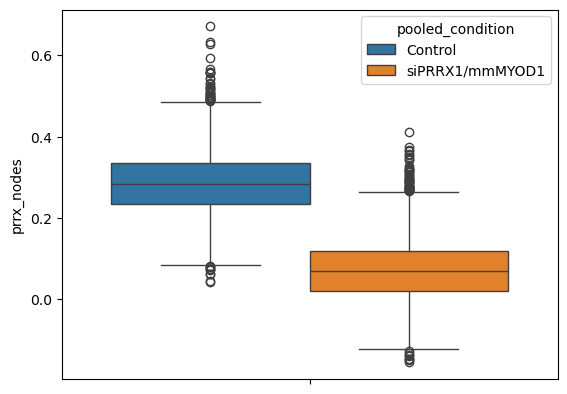

In [29]:
sc.tl.score_genes(
    fdata,
    gene_list=prrx_genes_robust,
    ctrl_size=len(prrx_genes_robust),
    score_name='prrx_nodes',
    layer='log_norm',
)

tmp = fdata.obs[['pooled_condition', 'prrx_nodes']].copy()
tmp.head()

display(tmp.groupby('pooled_condition', observed=True)['prrx_nodes'].describe())

sns.boxplot(
    data=tmp,
    y='prrx_nodes',
    hue='pooled_condition',
)

plt.show()

computing score 'myod_nodes'
    finished (0:00:01)


,count,mean,std,min,25%,50%,75%,max
pooled_condition,,,,,,,,
Control,6902.0,0.194238,0.030556,0.084261,0.173880,0.193597,0.214344,0.317221
siPRRX1/mmMYOD1,3456.0,0.167250,0.035859,0.027334,0.144017,0.166475,0.190697,0.339326


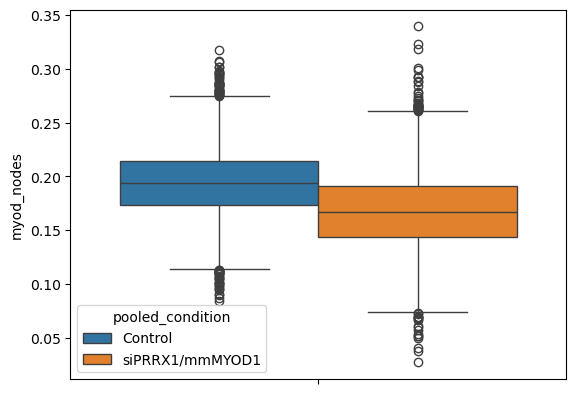

In [46]:
sc.tl.score_genes(
    fdata,
    gene_list=myod_genes_robust,
    ctrl_size=len(myod_genes_robust),
    score_name='myod_nodes',
    layer='log_norm',
)

tmp = fdata.obs[['pooled_condition', 'myod_nodes']].copy()
tmp.head()

display(tmp.groupby('pooled_condition', observed=True)['myod_nodes'].describe())

sns.boxplot(
    data=tmp,
    y='myod_nodes',
    hue='pooled_condition',
)

plt.show()